# DDH Dataset Coverage

This notebook documents the country coverage of the 4 ADM2 datasets available through the World Bank DDH API:

- **population** (DR0095354)
- **urbanization** (DR0095357)
- **nighttimelights** (DR0095356)
- **flood_exposure** (DR0095355)

In [1]:
import requests
import pandas as pd

BASE_URL = "https://datacatalogapi.worldbank.org/ddhxext/v3/resources"
DATASETS = {
    "population": "DR0095354",
    "urbanization": "DR0095357",
    "nighttimelights": "DR0095356",
    "flood_exposure": "DR0095355",
}

## Collect all ISO3 codes per dataset

Only fetch ISO3 + ADM2CD_c columns using `select`, with 1000 records per page via `top` — avoids downloading the full payload.

In [4]:
from collections import Counter

coverage = {}

for name, rid in DATASETS.items():
    url = f"{BASE_URL}/{rid}/data"
    
    # Only fetch ISO3 + ADM2CD_c columns, 1000 per page (vs default 100 with full payload)
    params = {"select": "ISO3,ADM2CD_c", "top": 1000}
    
    first_page = requests.get(url, params=params, timeout=60).json()
    total = first_page.get("count", 0)
    all_records = first_page.get("value", [])

    while len(all_records) < total:
        params["skip"] = len(all_records)
        page = requests.get(url, params=params, timeout=60).json()
        records = page.get("value", [])
        if not records:
            break
        all_records.extend(records)

    counts = Counter(r["ISO3"] for r in all_records)

    coverage[name] = {
        "total_records": len(all_records),
        "countries": sorted(counts.keys()),
        "n_countries": len(counts),
        "records_per_country": counts,
    }
    print(f"{name:20s} — {len(all_records):>6} records, {len(counts):>3} countries")

population           —  38734 records, 239 countries
urbanization         —  38734 records, 239 countries
nighttimelights      —  38734 records, 239 countries
flood_exposure       —  38734 records, 239 countries


## Coverage matrix

Which countries appear in which datasets?

In [5]:
# Build a coverage matrix: rows = ISO3, columns = datasets
all_countries = sorted(set().union(*(c["countries"] for c in coverage.values())))

matrix_data = []
for iso3 in all_countries:
    row = {"ISO3": iso3}
    for name in DATASETS:
        count = coverage[name]["records_per_country"].get(iso3, 0)
        row[name] = count
    row["in_all_4"] = all(row[name] > 0 for name in DATASETS)
    matrix_data.append(row)

matrix = pd.DataFrame(matrix_data).set_index("ISO3")

n_in_all = matrix["in_all_4"].sum()
print(f"Total unique countries across all datasets: {len(all_countries)}")
print(f"Countries in ALL 4 datasets: {n_in_all}")
print(f"Countries missing from at least 1: {len(all_countries) - n_in_all}")
print()
matrix

Total unique countries across all datasets: 239
Countries in ALL 4 datasets: 239
Countries missing from at least 1: 0



,population,urbanization,nighttimelights,flood_exposure,in_all_4
ISO3,,,,,
ABW,1,1,1,1,True
AFG,398,398,398,398,True
AGO,164,164,164,164,True
AIA,10,10,10,10,True
ALA,1,1,1,1,True
...,...,...,...,...,...
XKX,38,38,38,38,True
YEM,333,333,333,333,True
ZAF,52,52,52,52,True


In [9]:
# Highlight countries NOT in all 4 datasets
partial = matrix[~matrix["in_all_4"]].drop(columns="in_all_4")
print(f"Countries with partial coverage ({len(partial)}):\n")
# Replace 0 with "—" for readability
partial_display = partial.replace(0, "—")
partial_display

Countries with partial coverage (0):



,population,urbanization,nighttimelights,flood_exposure
ISO3,,,,


## Coverage consistency across datasets

Do all 4 datasets have the same countries and same record counts?

All 4 datasets have identical country lists: True

Record counts identical across all datasets: True


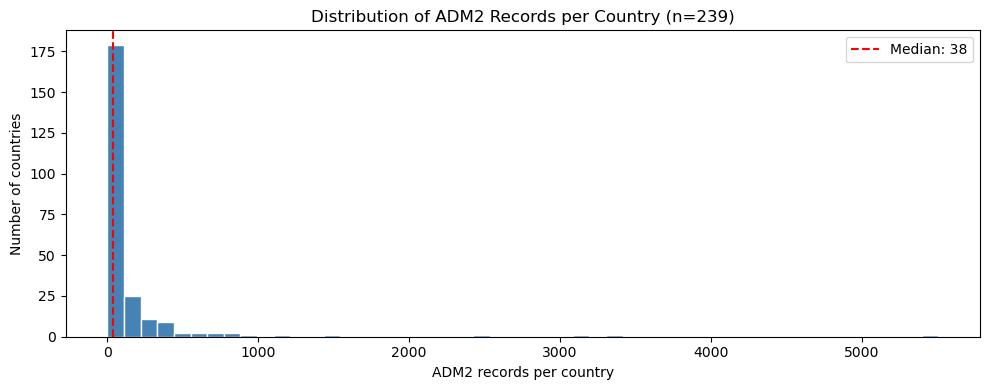

In [12]:
# Check if all 4 datasets have identical country sets
dataset_names = list(DATASETS.keys())
country_sets = {name: set(coverage[name]["countries"]) for name in dataset_names}

all_same = all(country_sets[dataset_names[0]] == country_sets[n] for n in dataset_names[1:])
print(f"All 4 datasets have identical country lists: {all_same}")

if not all_same:
    for i, n1 in enumerate(dataset_names):
        for n2 in dataset_names[i+1:]:
            diff1 = country_sets[n1] - country_sets[n2]
            diff2 = country_sets[n2] - country_sets[n1]
            if diff1 or diff2:
                print(f"\n{n1} vs {n2}:")
                if diff1: print(f"  Only in {n1}: {sorted(diff1)}")
                if diff2: print(f"  Only in {n2}: {sorted(diff2)}")

# Check if record counts per country are consistent across datasets
print(f"\nRecord counts identical across all datasets: ", end="")
pop_counts_dict = coverage["population"]["records_per_country"]
counts_match = all(
    coverage[name]["records_per_country"] == pop_counts_dict
    for name in dataset_names[1:]
)
print(counts_match)

# Distribution summary
fig, ax = plt.subplots(figsize=(10, 4))
records_series = pd.Series(pop_counts_dict).sort_values()
ax.hist(records_series, bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("ADM2 records per country")
ax.set_ylabel("Number of countries")
ax.set_title(f"Distribution of ADM2 Records per Country (n={len(records_series)})")
ax.axvline(records_series.median(), color="red", linestyle="--", label=f"Median: {records_series.median():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## Missing countries

Compare DDH ISO3 codes against the official ISO 3166-1 alpha-3 list to find gaps.

In [15]:
import pycountry

ddh_iso3 = set(all_countries)
official_iso3 = {c.alpha_3 for c in pycountry.countries}

missing = sorted(official_iso3 - ddh_iso3)
extra = sorted(ddh_iso3 - official_iso3)

print(f"Official ISO 3166-1 codes: {len(official_iso3)}")
print(f"DDH ISO3 codes:            {len(ddh_iso3)}")
print(f"Missing from DDH:          {len(missing)}")
print(f"In DDH but not official:   {len(extra)}")

missing_df = pd.DataFrame([
    {"ISO3": code, "Name": pycountry.countries.get(alpha_3=code).name}
    for code in missing
])
print(f"\nMissing from DDH ({len(missing)}):")
missing_df

Official ISO 3166-1 codes: 249
DDH ISO3 codes:            239
Missing from DDH:          11
In DDH but not official:   1

Missing from DDH (11):


,ISO3,Name
0,ATA,Antarctica
1,ESH,Western Sahara
2,FJI,Fiji
3,FLK,Falkland Islands (Malvinas)
4,HTI,Haiti
5,IOT,British Indian Ocean Territory
6,IRQ,Iraq
7,MLT,Malta
8,RUS,Russian Federation
9,SGS,South Georgia and the South Sandwich Islands


In [16]:
if extra:
    print(f"In DDH but not in official ISO 3166-1 ({len(extra)}):")
    for code in extra:
        print(f"  {code}  (e.g., XKX = Kosovo, a widely used provisional code)")
else:
    print("No extra codes in DDH beyond official ISO 3166-1")

In DDH but not in official ISO 3166-1 (1):
  XKX  (e.g., XKX = Kosovo, a widely used provisional code)


## Summary

- All 4 DDH datasets contain exactly **38,734 records** each
- Coverage is **global** — each dataset covers **239 countries**
- The coverage matrix and charts above show the distribution of ADM2 units per country